In [2]:
import organizar as orgn, funcoes as fn, pandas as pd

laureados = orgn.laureados()
nobelPorNac = orgn.nobelPorNac(laureados)
democracias = orgn.democracias()
populacao = fn.extrairPopulacao()
correl = fn.correlDemocrNobel(laureados, democracias, populacao)

In [22]:
dfMulheres = laureados.query("genero == 'female'")

total = (
    laureados.groupby(["decada", "categoria"])
        .size()
        .rename("total")
)

mulheres = (
    dfMulheres.groupby(["decada", "categoria"])
        .size()
        .rename("mulheres")
)

participacao = pd.concat([total, mulheres], axis=1)

participacao = participacao.reset_index()

participacao["mulheres"] = participacao["mulheres"].fillna(0)

participacao["percentual"] = (
    participacao["mulheres"] /
    participacao["total"] * 100
)


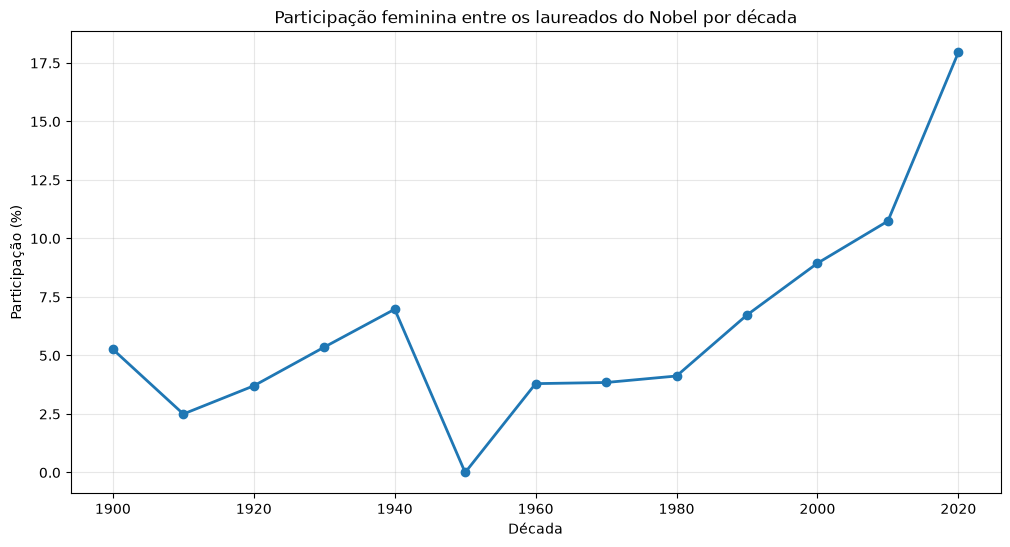

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    participacao_geral["decada"],
    participacao_geral["percentual"],
    marker="o",
    linewidth=2
)

plt.title("Participação feminina entre os laureados do Nobel por década")
plt.xlabel("Década")
plt.ylabel("Participação (%)")
plt.grid(alpha=0.3)

plt.show()

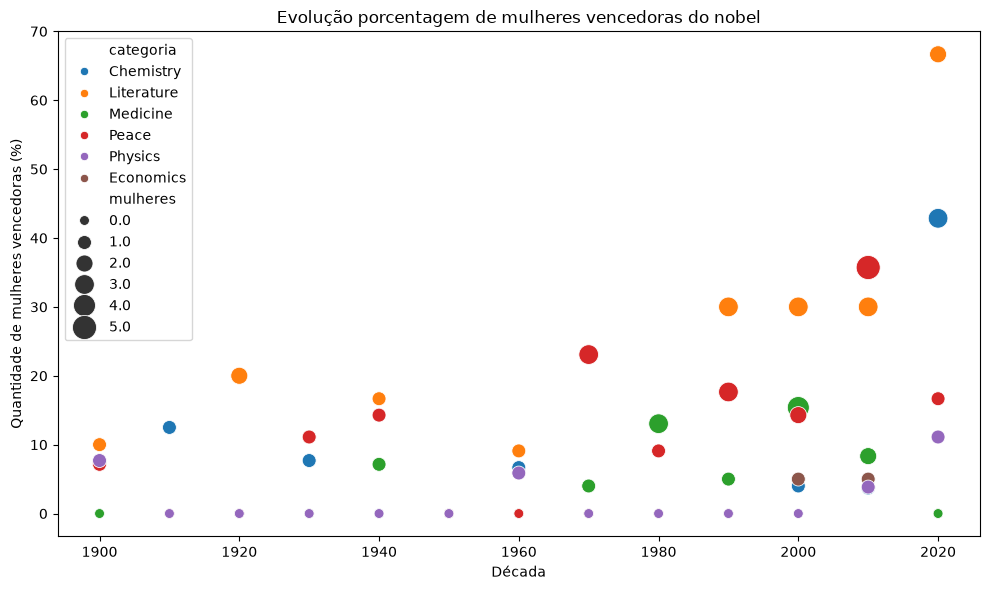

In [26]:
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=participacao,
    x="decada",   
    y="percentual",       
    size="mulheres",          
    sizes=(50, 300),
    hue="categoria",
    legend=True             
)

plt.title("Evolução porcentagem de mulheres vencedoras do nobel")
plt.xlabel("Década")
plt.ylabel("Quantidade de mulheres vencedoras (%)")
plt.tight_layout()
plt.show()

In [18]:
print(participacao.head())

   decada   categoria  total  mulheres  percentual
0    1900   Chemistry      9       0.0    0.000000
1    1900  Literature     10       1.0   10.000000
2    1900    Medicine     11       0.0    0.000000
3    1900       Peace     14       1.0    7.142857
4    1900     Physics     13       1.0    7.692308


In [21]:
dfMulheres = laureados.query("genero == 'female'")

total = (
    laureados.groupby("decada")
        .size()
        .rename("total")
)

mulheres = (
    dfMulheres.groupby("decada")
        .size()
        .rename("mulheres")
)

participacao_geral = pd.concat([total, mulheres], axis=1)

participacao_geral = participacao_geral.reset_index()

participacao_geral["mulheres"] = participacao_geral["mulheres"].fillna(0)

participacao_geral["percentual"] = (
    participacao_geral["mulheres"] /
    participacao_geral["total"] * 100
)